In [ ]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


import sys; sys.path.append("../src")
from ct_data import load_trial
from ct_plots import plot_trial, condition_subtitle


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [31]:
df = load_trial("003")

# --- derived columns (not measurements) ---
df["power_mW"] = (df["output_uA"] * 1e-3) * df["load_V"]
df["force_lbf"] = df["force_N"] * 0.224809

df.head(20)

,force_N,line_current_A,power_min_W,power_max_W,output_uA,load_V,ct,trial_id,date,force_lbf,power_mW
0,1.0,5.0,0.01,0.01,730,5,Nanocrystalline,003,2026-08-12,0.224809,3.650
1,1.5,5.1,0.01,0.01,795,5,Nanocrystalline,003,2026-08-12,0.337213,3.975
2,2.0,5.1,0.01,0.02,830,5,Nanocrystalline,003,2026-08-12,0.449618,4.150
3,2.5,5.0,0.01,0.02,830,5,Nanocrystalline,003,2026-08-12,0.562022,4.150
4,3.0,5.0,0.01,0.02,855,5,Nanocrystalline,003,2026-08-12,0.674427,4.275
5,3.5,5.0,0.01,0.02,875,5,Nanocrystalline,003,2026-08-12,0.786832,4.375
6,4.0,5.0,0.01,0.02,880,5,Nanocrystalline,003,2026-08-12,0.899236,4.400
7,4.5,5.0,0.01,0.02,890,5,Nanocrystalline,003,2026-08-12,1.011640,4.450
8,5.0,5.0,0.01,0.02,900,5,Nanocrystalline,003,2026-08-12,1.124045,4.500
9,5.5,5.0,0.01,0.02,925,5,Nanocrystalline,003,2026-08-12,1.236449,4.625


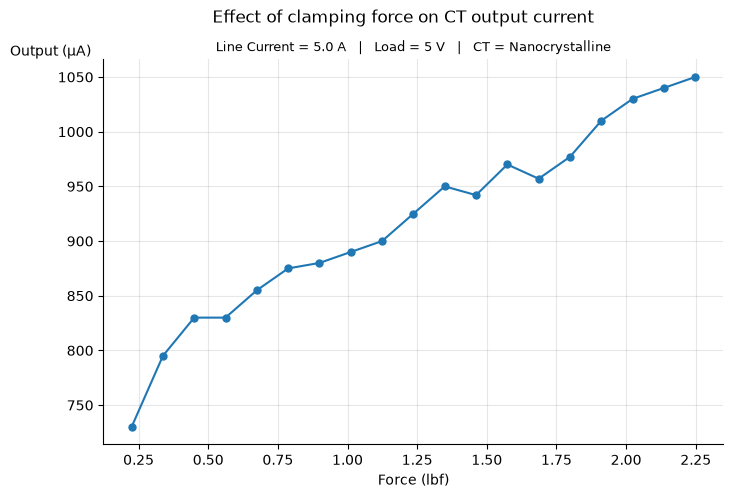

In [32]:
fig, ax = plot_trial(df, "force_lbf", "output_uA",
                     xlabel="Force (lbf)", ylabel="Output (µA)")

fig.suptitle("Effect of clamping force on CT output current")
ax.set_title(condition_subtitle(df), fontsize=9)

fig.savefig("../figures/trial_003_output_vs_force.png", dpi=300, bbox_inches="tight")

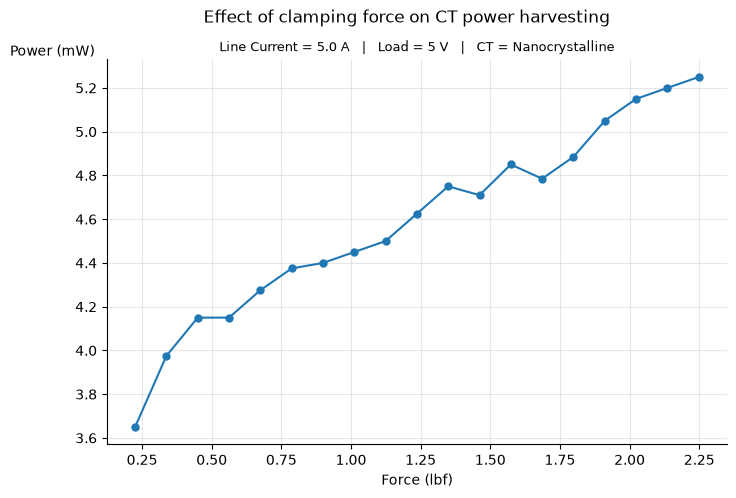

In [33]:
fig, ax = plot_trial(df, "force_lbf", "power_mW",
                     xlabel="Force (lbf)", ylabel="Power (mW)")

line, load, ct = df["line_current_A"].iloc[0], df["load_V"].iloc[0], df["ct"].iloc[0]
fig.suptitle("Effect of clamping force on CT power harvesting")
ax.set_title(condition_subtitle(df), fontsize=9)
fig.savefig("../figures/trial_003_harvesting_vs_force.png", dpi=300, bbox_inches="tight")